In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("data/default_of_credit_card_clients.xls",header=1)
df.rename(columns={"default payment next month": "default_payment_next_month"}, inplace=True)
df.shape

(30000, 25)

#### Two header rows in the raw file — header=1 skips the merged title row. Renamed the target column to remove spaces (breaks SQL/SHAP later otherwise).

### Checking missing values

In [3]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default_payment_next_month    0
dtype: int64

#### No true NaNs in this dataset — the real data-quality issue is invalid category codes, checked next.

In [4]:
# Target imbalance 
df['default_payment_next_month'].value_counts(normalize=True)

default_payment_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [5]:
# Invalid cateogory codes 
df['EDUCATION'].unique()
df['MARRIAGE'].unique()

array([1, 2, 3, 0])

In [6]:
# Sanity check numeric ranges
df[['LIMIT_BAL','AGE']].describe()

,LIMIT_BAL,AGE
count,30000.000000,30000.000000
mean,167484.322667,35.485500
std,129747.661567,9.217904
min,10000.000000,21.000000
25%,50000.000000,28.000000
50%,140000.000000,34.000000
75%,240000.000000,41.000000
max,1000000.000000,79.000000


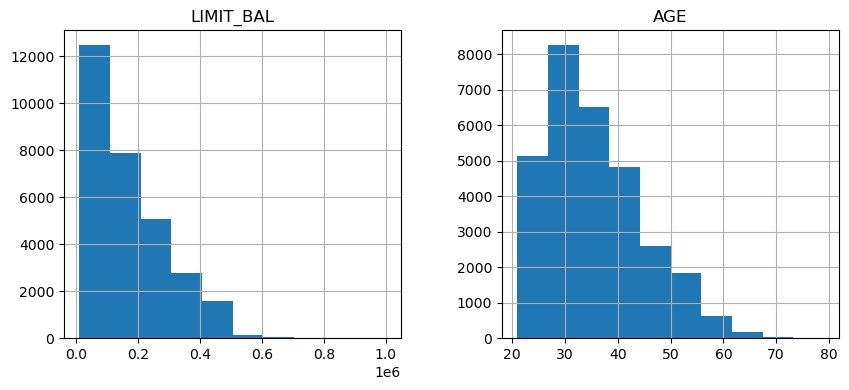

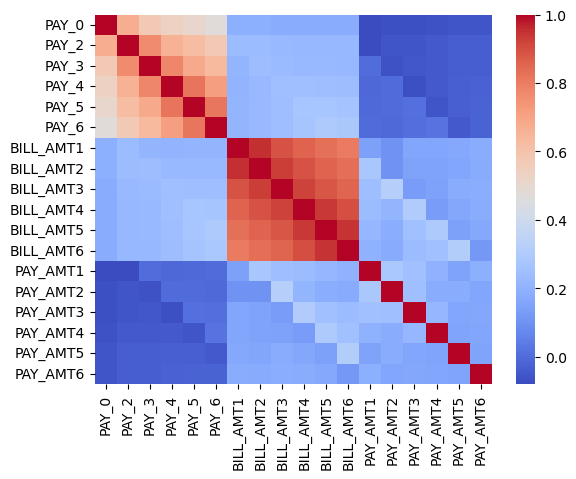

In [7]:
# Visual Exploration 

df[['LIMIT_BAL','AGE']].hist(figsize=(10,4))
plt.show()

corr_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
            'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
            'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

sns.heatmap(df[corr_cols].corr(),cmap="coolwarm")
plt.show()

## Summary — decisions carried into data_transformation.py
- EDUCATION/MARRIAGE: recode invalid codes to 'other', keep rows
- No numeric imputation needed (no NaNs) — median imputation kept in the
  pipeline anyway as a safety net for any future data drift
- Imbalance (~22.1%) → PR-AUC as primary metric, class-weight vs SMOTE compared
- PAY_0-PAY_6 aggregated into Total_Delay_Score (via SQL in ingestion)
- LIMIT_BAL bucketed into Credit_Limit_Tier (via SQL in ingestion)